# Content-Based NLP Recommendation Engine

## *What this notebook covers (Content-Based NLP Recommender*

1. *Problem* Framing & Data Ingestion: Loading the BigBasket product catalog.

2. Exploratory Data Analysis (EDA): Analyzing product categories, price distributions, and missing values.

3. Data Sanitization & Feature Engineering: Handling nulls, calculating discount percentages, and preparing text features.

4. NLP Text Preprocessing: Concatenating metadata (brand, category, description) into a unified text corpus.

5. Vectorization & Mathematical Modeling: Applying TF-IDF vectorization to convert text to a sparse numerical matrix.

6. Similarity Computation: Calculating Cosine Similarity to map relationships between 23,000+ products.

7. Recommendation Interface: Building and testing the inference function.

8. Artifact Export: Saving the similarity matrix and dataset via joblib for web deployment.

# 1. Import Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

from sklearn.metrics import classification_report, f1_score, confusion_matrix

import joblib

# 2. Load the Dataset

In [5]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("surajjha101/bigbasket-entire-product-list-28k-datapoints")
print("Path to dataset files:", path)

df = pd.read_csv(os.path.join(path, "BigBasket Products.csv"))
df.head()

Using Colab cache for faster access to the 'bigbasket-entire-product-list-28k-datapoints' dataset.
Path to dataset files: /kaggle/input/bigbasket-entire-product-list-28k-datapoints


,index,product,category,sub_category,brand,sale_price,market_price,type,rating,description
0,1,Garlic Oil - Vegetarian Capsule 500 mg,Beauty & Hygiene,Hair Care,Sri Sri Ayurveda,220.0,220.0,Hair Oil & Serum,4.1,This Product contains Garlic Oil that is known...
1,2,Water Bottle - Orange,"Kitchen, Garden & Pets",Storage & Accessories,Mastercook,180.0,180.0,Water & Fridge Bottles,2.3,"Each product is microwave safe (without lid), ..."
2,3,"Brass Angle Deep - Plain, No.2",Cleaning & Household,Pooja Needs,Trm,119.0,250.0,Lamp & Lamp Oil,3.4,"A perfect gift for all occasions, be it your m..."
3,4,Cereal Flip Lid Container/Storage Jar - Assort...,Cleaning & Household,Bins & Bathroom Ware,Nakoda,149.0,176.0,"Laundry, Storage Baskets",3.7,Multipurpose container with an attractive desi...
4,5,Creme Soft Soap - For Hands & Body,Beauty & Hygiene,Bath & Hand Wash,Nivea,162.0,162.0,Bathing Bars & Soaps,4.4,Nivea Creme Soft Soap gives your skin the best...


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27555 entries, 0 to 27554
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   index         27555 non-null  int64  
 1   product       27554 non-null  object 
 2   category      27555 non-null  object 
 3   sub_category  27555 non-null  object 
 4   brand         27554 non-null  object 
 5   sale_price    27555 non-null  float64
 6   market_price  27555 non-null  float64
 7   type          27555 non-null  object 
 8   rating        18929 non-null  float64
 9   description   27440 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 2.1+ MB


In [7]:
df.describe()

,index,sale_price,market_price,rating
count,27555.00000,27555.000000,27555.000000,18929.000000
mean,13778.00000,322.514808,382.056664,3.943410
std,7954.58767,486.263116,581.730717,0.739063
min,1.00000,2.450000,3.000000,1.000000
25%,6889.50000,95.000000,100.000000,3.700000
50%,13778.00000,190.000000,220.000000,4.100000
75%,20666.50000,359.000000,425.000000,4.300000
max,27555.00000,12500.000000,12500.000000,5.000000


In [8]:
df.shape

(27555, 10)

# 3. Exploratory Data Analysis

## *We explore the data in the standard order every ML engineer follows:*

1. Missing values

2. Univariate analysis (one variable at a time — distributions, skewness)

3. Bivariate analysis (relationship between features and the target)

4. Correlation between numeric features

5. Outlier inspection

## 3.1 Missing Values

In [9]:
missing = df.isnull().sum()
missing[missing > 0]

,0
product,1
brand,1
rating,8626
description,115


## 3.2 Text Data Sanitization

In [10]:
# Drop rows missing critical text data
df = df.dropna(subset=['product', 'brand', 'description'])

# Drop the rating column completely (31% missing is too high to impute safely for this project)
df = df.drop(columns=['rating'])

# Verify the final clean state
print("Remaining missing values:")
print(df.isnull().sum())
print("-" * 30)
print(f"Final dataset shape: {df.shape}")

Remaining missing values:
index           0
product         0
category        0
sub_category    0
brand           0
sale_price      0
market_price    0
type            0
description     0
dtype: int64
------------------------------
Final dataset shape: (27439, 9)


### 3.3 Univariate Analysis

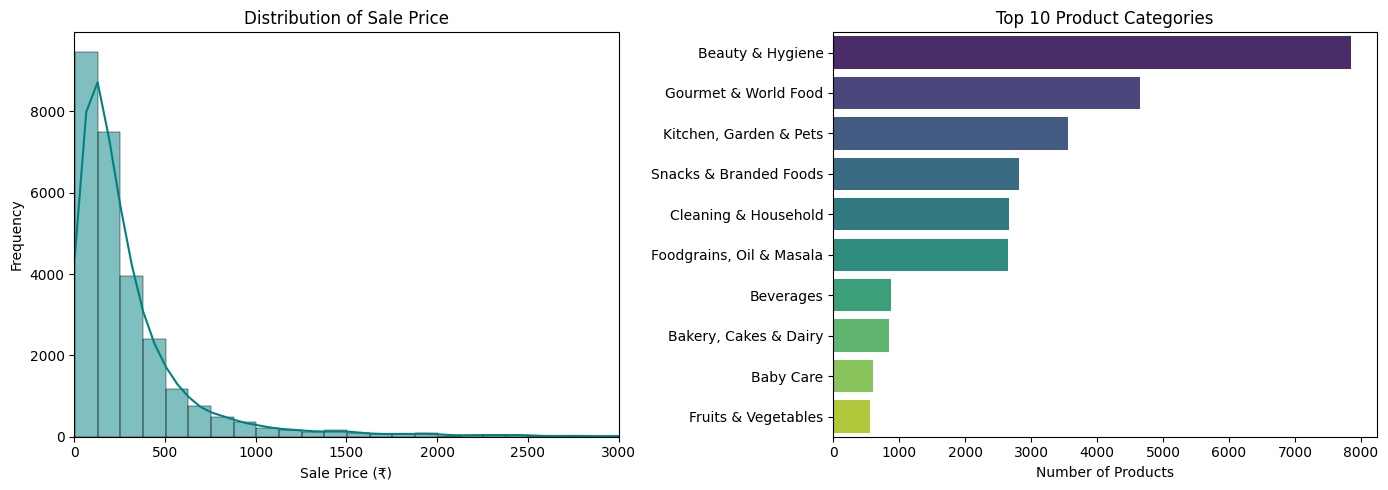

In [11]:
plt.figure(figsize=(14, 5))

# 1. Distribution of Sale Price
plt.subplot(1, 2, 1)
sns.histplot(df['sale_price'], bins=100, kde=True, color='teal')
plt.title('Distribution of Sale Price')
plt.xlabel('Sale Price (₹)')
plt.ylabel('Frequency')
plt.xlim(0, 3000) # Zooming in on the majority of the data

# 2. Top 10 Categories
plt.subplot(1, 2, 2)
sns.countplot(y='category', data=df, order=df['category'].value_counts().head(10).index, palette='viridis')
plt.title('Top 10 Product Categories')
plt.xlabel('Number of Products')
plt.ylabel('')

plt.tight_layout()
plt.show()

### 3.4 Feature Engineering & Bivariate Analysis

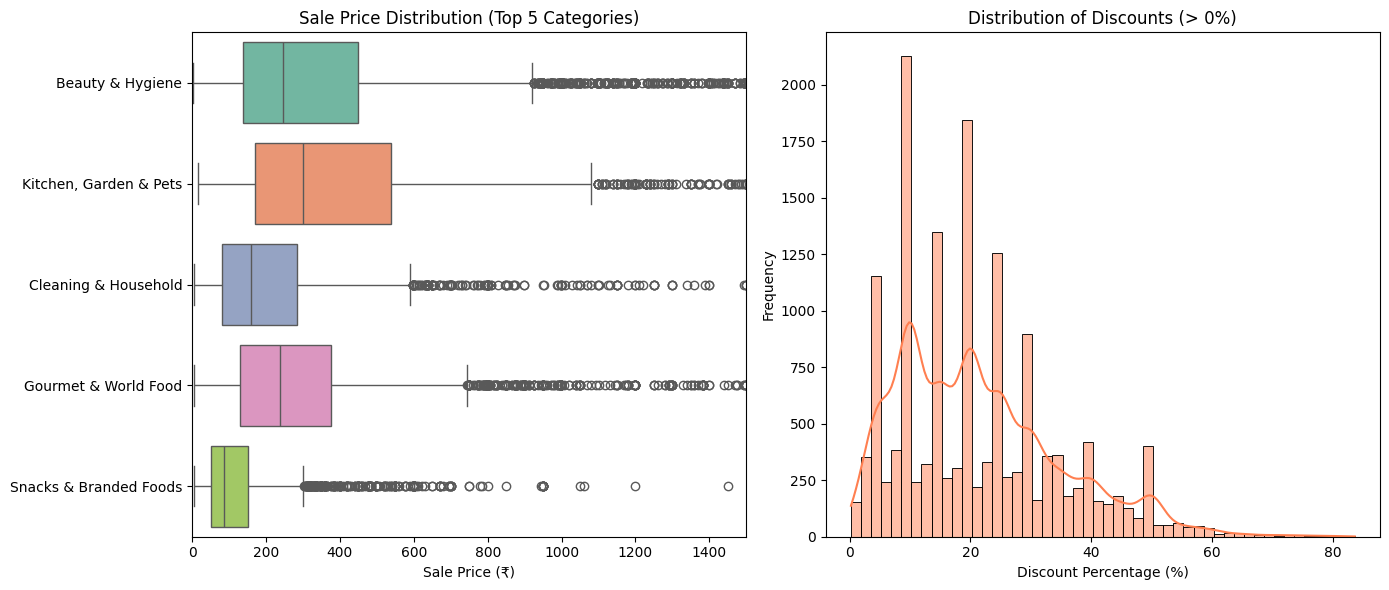

,product,market_price,sale_price,discount_percent
0,Garlic Oil - Vegetarian Capsule 500 mg,220.0,220.0,0.000000
1,Water Bottle - Orange,180.0,180.0,0.000000
2,"Brass Angle Deep - Plain, No.2",250.0,119.0,52.400000
3,Cereal Flip Lid Container/Storage Jar - Assort...,176.0,149.0,15.340909
4,Creme Soft Soap - For Hands & Body,162.0,162.0,0.000000


In [12]:
# 1. Feature Engineering: Create a Discount Percentage column
df['discount_percent'] = ((df['market_price'] - df['sale_price']) / df['market_price']) * 100

# 2. Bivariate Analysis: Sale Price by Top 5 Categories
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
top_5_cats = df['category'].value_counts().head(5).index
sns.boxplot(x='sale_price', y='category', data=df[df['category'].isin(top_5_cats)], palette='Set2')
plt.title('Sale Price Distribution (Top 5 Categories)')
plt.xlim(0, 1500) # Zoomed in for clarity
plt.xlabel('Sale Price (₹)')
plt.ylabel('')

# 3. Distribution of Discounts
plt.subplot(1, 2, 2)
sns.histplot(df[df['discount_percent'] > 0]['discount_percent'], bins=50, color='coral', kde=True)
plt.title('Distribution of Discounts (> 0%)')
plt.xlabel('Discount Percentage (%)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Display the new feature
df[['product', 'market_price', 'sale_price', 'discount_percent']].head()

# 4. Text Preprocessing for NLP


In [13]:
# 1. Build composite text corpus across core catalog attributes
metadata_fields = ['brand', 'category', 'sub_category', 'description']
df['tags'] = df[metadata_fields].astype(str).agg(' '.join, axis=1).str.lower()

# 2. Isolate unique SKUs to eliminate redundant similarity calculations
df_recommender = (
    df[['product', 'tags', 'sale_price']]
    .drop_duplicates(subset=['product'])
    .reset_index(drop=True)
)

# 3. Verify corpus integrity
print(f"Unique catalog items: {len(df_recommender):,}")
df_recommender.head(3)

Unique catalog items: 23,449


,product,tags,sale_price
0,Garlic Oil - Vegetarian Capsule 500 mg,sri sri ayurveda beauty & hygiene hair care t...,220.0
1,Water Bottle - Orange,"mastercook kitchen, garden & pets storage & ac...",180.0
2,"Brass Angle Deep - Plain, No.2",trm cleaning & household pooja needs a perfect...,119.0


# 5. TF-IDF Vectorization & Cosine Similarity

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1. Initialize TF-IDF Vectorizer
# We limit to the top 5000 features to optimize RAM and remove common stop words ('and', 'the', etc.)
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

# 2. Transform the text corpus into a sparse numerical matrix
tfidf_matrix = tfidf.fit_transform(df_recommender['tags'])
print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")

# 3. Compute the Cosine Similarity matrix
# This computes a 23k x 23k matrix and may take 10-20 seconds
similarity_matrix = cosine_similarity(tfidf_matrix)
print(f"Similarity Matrix Shape: {similarity_matrix.shape}")

TF-IDF Matrix Shape: (23449, 5000)
Similarity Matrix Shape: (23449, 23449)


# 6. Building the Recommendation *Interface*

In [15]:
import pandas as pd

# 1. Create a reverse mapping of product names to dataframe indices
indices = pd.Series(df_recommender.index, index=df_recommender['product']).drop_duplicates()

# 2. Define the recommendation engine function
def get_recommendations(product_name, cosine_sim=similarity_matrix):
    # Check if product exists to prevent errors
    if product_name not in indices:
        return "Product not found in the catalog. Please try another search."

    # Get the index of the product that matches the title
    idx = indices[product_name]

    # Get the pairwise similarity scores of all products with that product
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort the products based on the similarity scores (highest to lowest)
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get the scores of the 5 most similar products (ignoring index 0, which is the product itself)
    sim_scores = sim_scores[1:6]

    # Get the product indices
    product_indices = [i[0] for i in sim_scores]

    # Return the top 5 recommendations with their prices
    return df_recommender[['product', 'sale_price']].iloc[product_indices]

# 3. Test the engine with a product from the dataset
print("Recommendations for 'Garlic Oil - Vegetarian Capsule 500 mg':\n")
get_recommendations('Garlic Oil - Vegetarian Capsule 500 mg')

Recommendations for 'Garlic Oil - Vegetarian Capsule 500 mg':



,product,sale_price
754,Evening Primrose Oil - Vegetarian Capsule (500...,295.0
14664,"Flaxseed Oil - Omega-3, Omega-6, Omega-9 Veget...",235.0
9791,Brahmi Bhringaraj Taila - Anti Graying,70.0
18771,Orange Face Wash - Feel of Freshness,51.0
15862,Shakti Drops - Immunity Booster,110.0


In [16]:
import joblib

# Save the similarity matrix and the clean dataframe
joblib.dump(similarity_matrix, 'similarity_matrix.pkl')
joblib.dump(df_recommender, 'df_recommender.pkl')

print("Model and dataset successfully exported!")

Model and dataset successfully exported!
